In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('iris.csv')
df.head()
dfs = df.sample(10)
pd.set_option('display.width', 100)
print(dfs)

     Unnamed: 0  sepal.length  sepal.width  petal.length  petal.width     variety
112         112           6.8          3.0           5.5          2.1   Virginica
60           60           5.0          2.0           3.5          1.0  Versicolor
100         100           6.3          3.3           6.0          2.5   Virginica
30           30           4.8          3.1           1.6          0.2      Setosa
31           31           5.4          3.4           1.5          0.4      Setosa
28           28           5.2          3.4           1.4          0.2      Setosa
107         107           7.3          2.9           6.3          1.8   Virginica
80           80           5.5          2.4           3.8          1.1  Versicolor
121         121           5.6          2.8           4.9          2.0   Virginica
131         131           7.9          3.8           6.4          2.0   Virginica


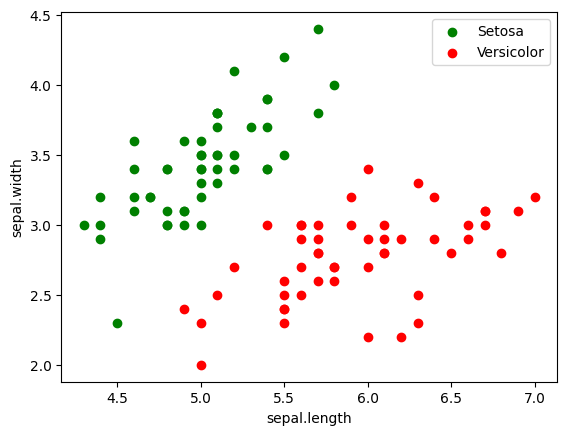

In [2]:
df.replace(to_replace='Setosa',value= '1', inplace=True)
df.replace(to_replace='Versicolor',value= '0', inplace=True)
indexAge = df[ df['variety'] == 'Virginica' ].index
df.drop(indexAge , inplace=True)
df_g=df.groupby('variety')
df_1=df_g.get_group('1')
df_0=df_g.get_group('0')
plt.scatter(df_1['sepal.length'],df_1['sepal.width'],color='g')
plt.scatter(df_0['sepal.length'],df_0['sepal.width'],color='r')
plt.xlabel('sepal.length')
plt.ylabel('sepal.width')
plt.legend(['Setosa','Versicolor'])
plt.show()


[[-3.08267284  3.01867739]] [7.33819169] 



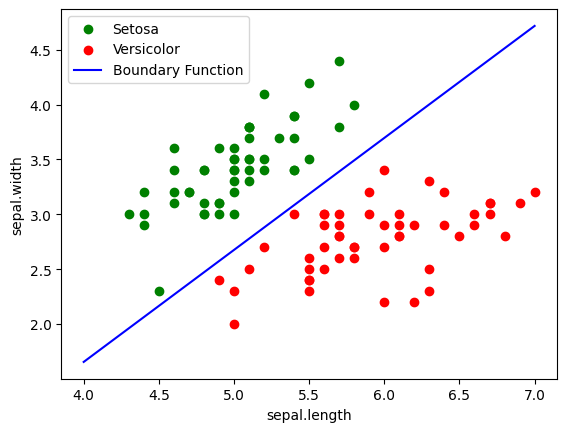

In [3]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(df[['sepal.length','sepal.width']], df['variety'])
print(model.coef_, model.intercept_,'\n')

coef=model.coef_
bias=model.intercept_
m=-1*coef[0,0]/coef[0,1]
b=-1*bias/coef[0,1]
xline=np.array([4,7])
yline=m*xline+b

df_g=df.groupby('variety')
df_1=df_g.get_group('1')
df_0=df_g.get_group('0')
plt.scatter(df_1['sepal.length'],df_1['sepal.width'],color='g')
plt.scatter(df_0['sepal.length'],df_0['sepal.width'],color='r')
plt.xlabel('sepal.length')
plt.ylabel('sepal.width')
plt.plot(xline,yline,'b')
plt.legend(['Setosa','Versicolor','Boundary Function'])

plt.show()

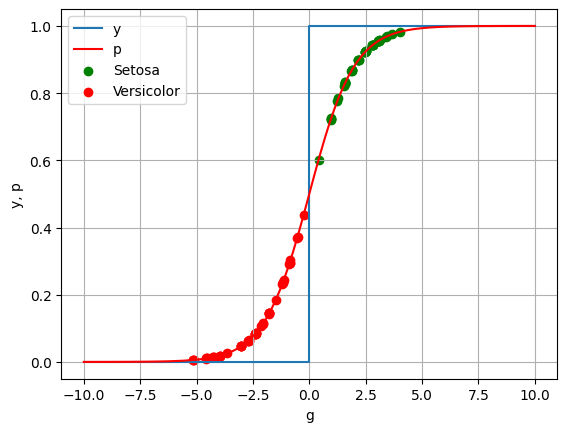

In [4]:
gstep = np.array([-10, 0, 10])
ystep = np.array([0, 0, 1])

xp = np.linspace(-10, 10, 100)
zp = 1/(1 + np.exp(-xp))


plt.step(gstep, ystep)
plt.plot(xp, zp, color='r')
plt.xlabel('g')
plt.ylabel('y, p')
plt.grid()

yh=model.predict(df[['sepal.length','sepal.width']])
yh1 = np.array([i for i, x1 in enumerate(yh) if x1 == '1'])
yh0 = [i for i, x1 in enumerate(yh) if x1 == '0']


p=model.predict_proba(df[['sepal.length','sepal.width']])
featureValues=np.array(df[['sepal.length','sepal.width']].values)
log_odds = np.matmul(model.coef_ , np.transpose(featureValues))+ model.intercept_

plt.scatter(log_odds[0,yh1],p[yh1,1],color='g')
plt.scatter(log_odds[0,yh0],p[yh0,1],color='r')
plt.legend(['y','p','Setosa','Versicolor'])
plt.show()

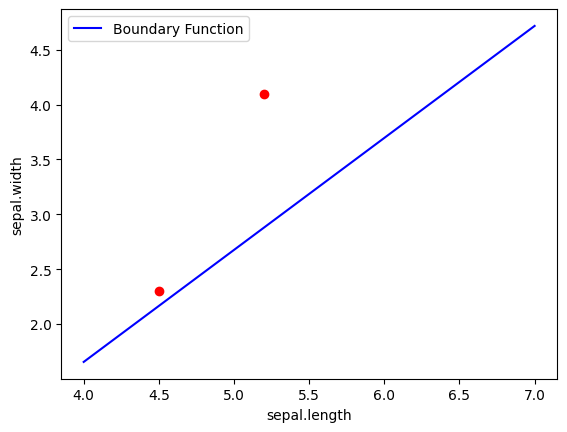

p(Setosa)
 0.6008773069996068 
 0.9755141725037374 

odd(Setosa)
 1.5054952212376833 
 39.839951198407945 

log_odd
 0.40912189473181293 
 3.684870207776086


In [7]:
plt.xlabel('sepal.length')
plt.ylabel('sepal.width')
plt.plot(xline,yline,'b')
plt.legend(['Boundary Function'])
n1=41
n2=32
plt.scatter(df['sepal.length'][n1],df['sepal.width'][n1],color='r')
plt.scatter(df['sepal.length'][n2],df['sepal.width'][n2],color='r')
plt.show()

p=model.predict_proba(df[['sepal.length','sepal.width']])
print('p(Setosa)\n', p[n1,1],'\n', p[n2,1],'\n')
odds=p/(1-p)
print('odd(Setosa)\n', odds[n1,1],'\n',odds[n2,1],'\n')
featureValues=np.array(df[['sepal.length','sepal.width']].values)
log_odds = np.matmul(model.coef_ , np.transpose(featureValues))+ model.intercept_
print('log_odd\n',log_odds[0,n1],'\n',log_odds[0,n2])